In [1]:
#Run PCA on X and Y - March 2024
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import seaborn as sns  # Optional for aesthetics
import datetime
import numpy as np

data_path  = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0/'
fig_path   = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_fig15/'
shape_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15/'

In [58]:
#Load all
file_list = glob.glob(shape_path + '*.nc')
ds = xr.open_dataset(file_list[1000])
ds

<xarray.Dataset>
Dimensions:  (time: 1, C15x: 980, C15y: 980)
Coordinates:
  * time     (time) datetime64[ns] 1981-05-03T12:00:00
  * C15x     (C15x) float64 -2.538e+03 -2.512e+03 ... -2.512e+03 -2.512e+03
  * C15y     (C15y) float64 1.338e+03 1.312e+03 ... 1.388e+03 1.362e+03
Data variables:
    *empty*
Attributes: (12/43)
    title:                     Sea Ice Concentration Climate Data Record Vers...
    summary:                   This climate data record of sea ice concentrat...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -16.62393
    geospatial_lon_min:        -180.0
    ...                        ...
    algorithm:                 SICCI3LF (19V, 37V, 37H)
    references:                Product User Manual v3 (2022),Algorithm Theore...
    contributor_name:          Thomas Lavergne,Atle Soerensen,Rasmus Tonboe,C...
    contributor_role:          PrincipalInvestigator,author,author,author,aut...
    source:                    FCDR of SMMR / SSMI / SSMIS Brightness Tempera...
    product_status:            released

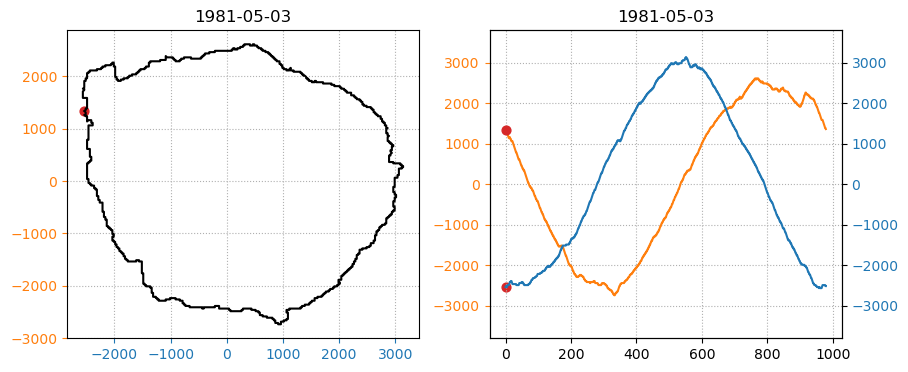

In [59]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize = (10,4))
ax1.plot(ds.C15x,ds.C15y,c = 'black')
ax1.scatter(ds.C15x[0],ds.C15y[0],c = 'tab:red',s = 40)
ax1.set_title(str(ds.time.data[0])[0:10])
ax1.tick_params(axis='x', colors='tab:blue')
ax1.tick_params(axis='y', colors='tab:orange')

ax2.plot(ds.C15y, c='tab:orange')
ax2.scatter(0,ds.C15x[0],c = 'tab:red',s = 40)
ax2.set_title(str(ds.time.data[0])[0:10])
ax2.tick_params(axis='y', colors='tab:orange')

ax_right = ax2.twinx()  # instantiate a second axes that shares the same x-axis
ax_right.plot(ds.C15x, c='tab:blue')
ax_right.scatter(0,ds.C15y[0],c = 'tab:red',s = 40)
ax_right.tick_params(axis='y', labelcolor='tab:blue')

ny = 3800
ax2.set_ylim([-ny,ny])
ax_right.set_ylim([-ny,ny])

ax1.grid(linestyle = 'dotted')
ax2.grid(linestyle = 'dotted')
plt.savefig('Contour_' + str(ds.time.data[0])[0:10] + '.png')
#plt.close()
